In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from get_model_probabilities import *
filter_color = {'f115w':'c', 'f150w':'pink','concat':'k'}
from scipy.stats import binned_statistic
from add_shear_to_data import combine_catalogues
from scipy.ndimage import zoom
import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [7]:
def g1_func( snr, a, b, c, d ):
    return a + b*np.exp( snr /c) + d*snr
    #return a + b*snr + c*snr**2
    #return a+b*snr

def g1_inv( snr, a, b, c, d):
    
    #return np.log((snr - a)/b)*c
    
    z =  b/(c*d)*np.exp((snr-a)/(c*d))
    
    return ( snr - a)/d - c*lambertw(z)
    #return (snr -a)/b
    
def jacob( snr, a, b, c, d):

    z = b/(c*d)*np.exp((snr-a)/(c*d))
    
    deriv = 1. / (d*(1+lambertw(z) ))
    #deriv = c*lambertw(z) / (z*(1+lambertw(z) ))
    return deriv

    #return c/(snr-a)
    #return 1./b

In [8]:
def get_model_estimates( 
    data, all_models,
):
    probabilities_filt = []
    with torch.no_grad():

        for imodel in all_models:
            outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
            #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
            #   continue
            probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[0,0]) 
    return torch.tensor( probabilities_filt).detach().numpy()


def get_all_model_estimates( 
    data, all_models,
):
    probabilities_filt = []
    with torch.no_grad():

        for imodel in all_models:
            outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
            #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
            #   continue
            probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )) 
    return torch.stack( probabilities_filt).detach().numpy()

In [339]:
obs_meta, obs_data = pkl.load(open(f"../data/100/a2744/obs_data_concat.pkl","rb"))
obs_cat = combine_catalogues(
    "../data/100/a2744/a2744_f115w_filtered.fits",
    "../data/100/a2744/a2744_f150w_filtered.fits"
)


if np.max(obs_cat['x']) > 1000:
    ra,dec = ra_dec_to_simulation_image_pos( obs_cat)
    obs_cat['x'] = ra
    obs_cat['y'] = dec
image_size  = 100
obs_kappa_e, obs_kappa_b = get_kappa(
    obs_cat, smooth=1.5, correct_for_ngal=True, extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
)

In [71]:
args.log_mass_cut = 15
args.source_domain = 'darkskies_obs'
args.target_domain = 'bahamas_obs'
args.apply_intrinsic_ell = 0.
args.zs = 1.65
args.verbose = False
dataloaders = prepare_dataloaders(args)
ifilter='concat'

# Independent blocks such that the final size of the image is 100 / segement_size
-----

## First on data
---

In [924]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'

probabilities = {}
cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]
all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")
meta, data = pkl.load(open(f"../data/100/a2744/obs_data_{ifilter}.pkl","rb"))

segment_size = 1 # pixels
nsegments = data.shape[-1]//segment_size

probabilities = np.zeros( (nsegments, nsegments,len(all_models) ))

fiducial = get_model_estimates( data[:2,:,:,:], all_models)

for isx in tqdm(range(nsegments)):
      for isy in range(nsegments):
            segmented_data = data[:2,:,:,:].copy()
            
            segmented_data[0, :, 
                isx*segment_size:(isx+1)*segment_size,
                isy*segment_size:(isy+1)*segment_size
            ] = np.median(segmented_data)
            
            
            probabilities[isx,isy,:] = (1.-get_model_estimates( segmented_data, all_models))
            




pkl.dump([fiducial,probabilities],open(f"pickles/senstivity_{segment_size}.pkl","wb"))           

Found 5 Models


  0%|                                                      | 0/100 [00:00<?, ?it/s]


NameError: name 'sys' is not defined

## Try to find good clusters to use an examples

### Use bahamas SIDM 1

#### Find the models with the highest sidm score as a good example

BEST CDM (dont forget to add 1800) [1085  183  655 ... 1788 1602   22]


(array([   6.,  142.,  807., 1324.,  853.,  302.,   92.,   48.,   15.,
          11.]),
 array([0.4343569 , 0.44191596, 0.44947502, 0.45703408, 0.46459314,
        0.47215223, 0.47971129, 0.48727036, 0.49482942, 0.50238848,
        0.50994754]),
 <BarContainer object of 10 artists>)

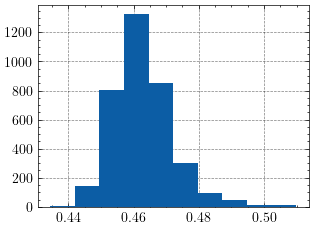

In [652]:
meta, data = pkl.load(open("../data/100/obs/concat/bahamas_cdm.pkl","rb"))
all_data = []
index_use = np.arange(data.shape[0])
for i in index_use:
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)

cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))


all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
cdm_fiducial = 1-get_all_model_estimates( forward_modelled, all_models)
print(f"BEST CDM (dont forget to add {cdm_fiducial.shape[1]//2})",np.mean(cdm_fiducial[:,cdm_fiducial.shape[1]//2:,0],axis=0).argsort()[::-1])
plt.hist(np.mean(cdm_fiducial[:,:,0],axis=0))



BEST SIDM (dont forget to add 1800) [1384 1632  750 ... 1442  533 1360]


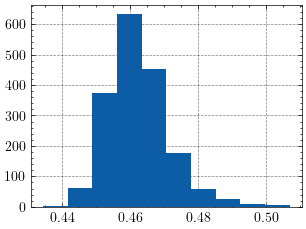

In [7]:
meta, data = pkl.load(open("../data/100/obs/concat/bahamas_1.pkl","rb"))
all_data = []
index_use = np.arange(data.shape[0])
for i in index_use:
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)

cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))


all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
fiducial = 1-get_all_model_estimates( forward_modelled, all_models)
print(f"BEST SIDM (dont forget to add {fiducial.shape[1]//2})",np.mean(fiducial[:,fiducial.shape[1]//2:,0],axis=0).argsort()[::-1])
plt.hist(np.mean(fiducial[:,fiducial.shape[1]//2:,0],axis=0))
bah_best_indexes = np.mean(fiducial[:,:,0],axis=0).argsort()[::-1]
pkl.dump(bah_best_indexes,open("pickles/bah_best_indexes.pkl","wb"))

## Now run the best cluster here - Use DARKSKIES CDM & 0.2 with halo 91

In [81]:
meta, data = pkl.load(open("../data/100/obs/concat/merger_91_allcross.pkl","rb"))
all_data = []
ds_index_use = np.arange(4)/4*data.shape[0]
for i in ds_index_use:
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[int(i),:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)

In [509]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]


#cdan_models = np.sort(glob(
#    f"../models/base_models/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_final.pth"
#))



all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")


for segment_size in [2]: # pixels
    nsegments = forward_modelled.shape[-1]//segment_size

    sim_probabilities = np.zeros( (forward_modelled.shape[0], nsegments, nsegments,len(all_models) ))

    fiducial = get_all_model_estimates( forward_modelled, all_models)

    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = forward_modelled.copy()

                segmented_data[:, :, 
                    isx*segment_size:(isx+1)*segment_size,
                    isy*segment_size:(isy+1)*segment_size
                ] = np.median(np.median(segmented_data,axis=-1),axis=-1)[:,:,None,None]

                
                this_estimate = (1.-get_all_model_estimates( segmented_data, all_models))
                
                for i in range(forward_modelled.shape[0]):
                    sim_probabilities[i,isx,isy,:] = this_estimate[:,i,0]






    pkl.dump([ 1-fiducial, sim_probabilities],open(f"pickles/sim_senstivity_{segment_size}_halo91.pkl","wb"))                        

Found 5 Models


100%|█████████████████████████████████████████████| 50/50 [02:01<00:00,  2.42s/it]


NameError: name 'bahamas_index_use' is not defined

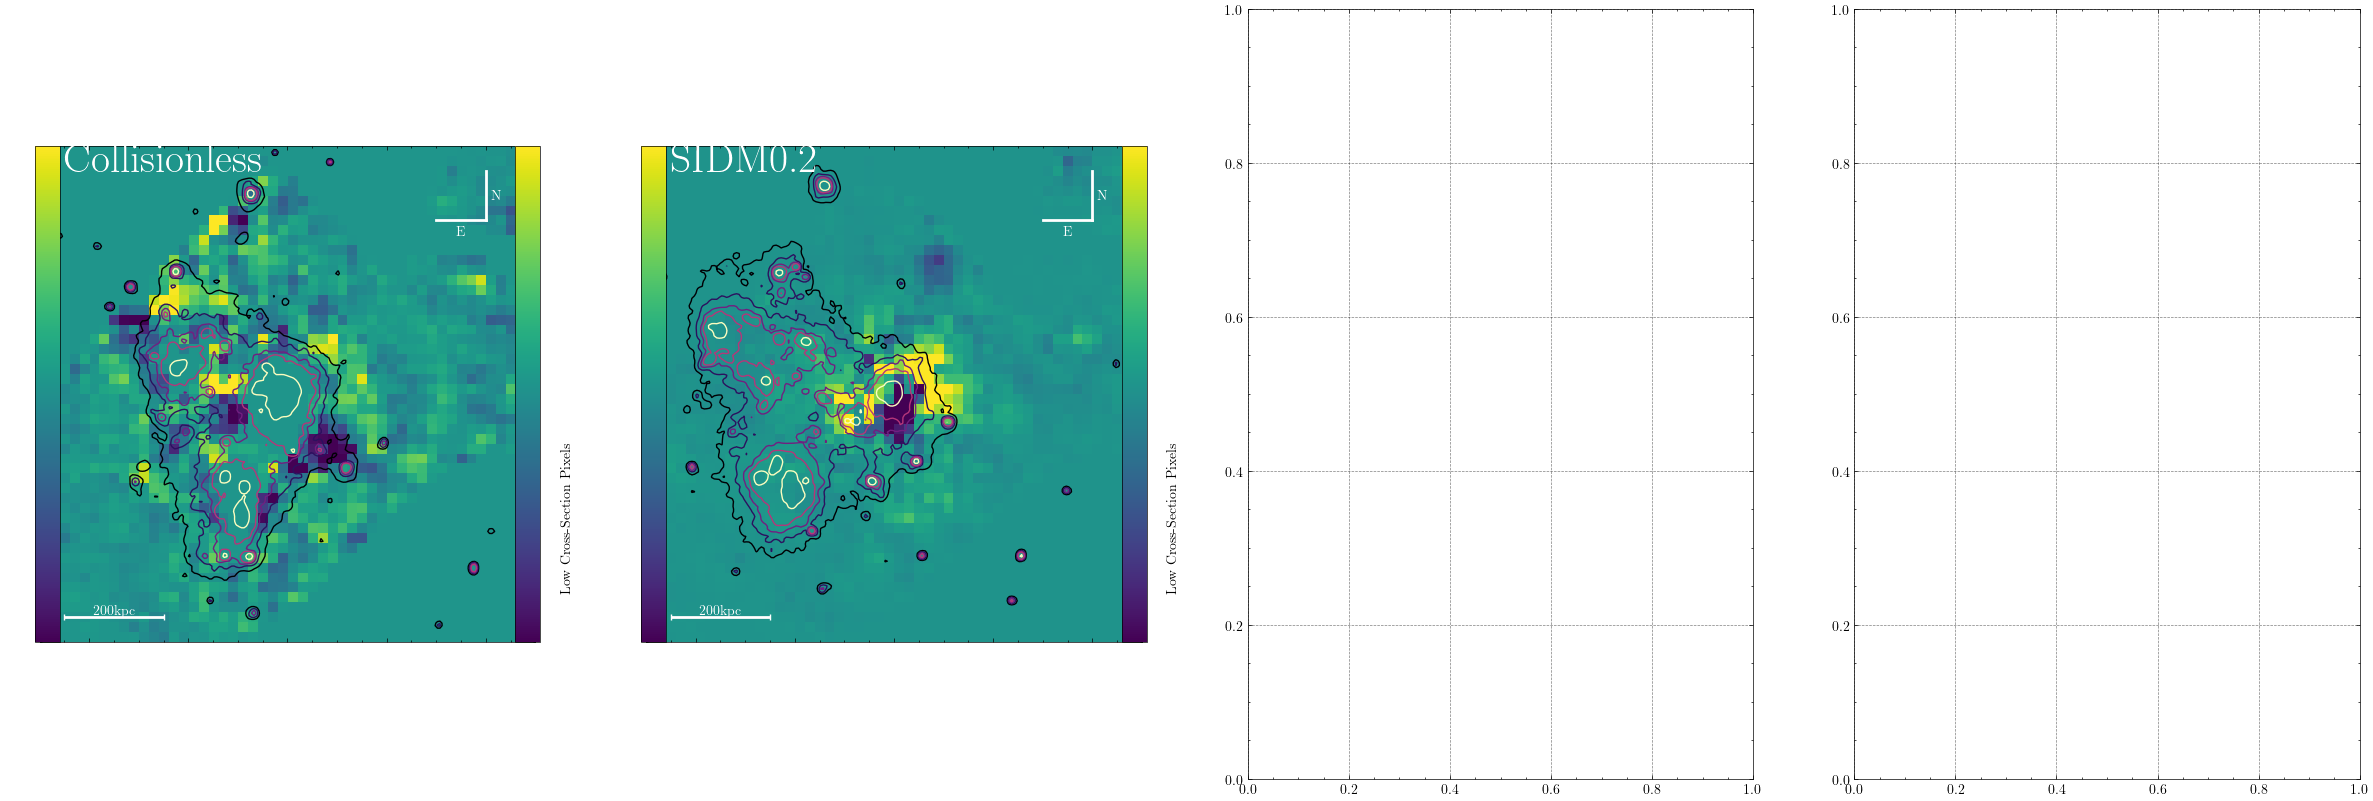

In [511]:
fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}test.pkl","rb"))      

fig, axarr=plt.subplots(1, sim_probabilities.shape[0]+1,figsize=(30, 10))

kappas = []
contrast=4
ds_index_use = 91

dmlabel = ['Collisionless', 'SIDM0.2','SIDM1']
for idm in range(sim_probabilities.shape[0]):
    
    if idm < 2:
        meta, kappa_data = pkl.load(open("../data/100/shear/merger.pkl","rb"))
        meta, data = pkl.load(open("../data/100/obs/concat/merger.pkl","rb"))
        kappa_e = kappa_data[ds_index_use+idm*data.shape[0]//2,2,:,:]

    else:
        meta, kappa_data = pkl.load(open("../data/100/shear/merger_bahamas.pkl","rb"))
        meta, data = pkl.load(open("../data/100/obs/concat/merger_bahamas.pkl","rb"))
        kappa_e = kappa_data[bahamas_index_use[idm-2],2,:,:]


    relative_prob = np.mean(fiducial[:,idm,0] - sim_probabilities[idm], axis=-1)
    kappas.append(kappa_e)
    ax = axarr[idm]
    
    cmap_contour = 'magma'
    cmap_image = 'viridis'
    vmin = np.mean(relative_prob)  - contrast*relative_prob.std()
    vmax = np.mean(relative_prob)   + contrast*relative_prob.std()

    imax = ax.imshow(relative_prob, 
                     origin='lower', extent=[-50,50,-50,50],
                     vmin=vmax, vmax=vmin,
                     cmap=cmap_image)
    #

    ax.contour(zoom(kappa_e,2), origin='lower', 
                   extent=[-50,50,-50,50], 
               cmap=cmap_contour, 
               levels=[0.4,0.5,0.6,0.7,1.0])
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=-0.2)
    cbar = fig.colorbar(imax, cax=cax, orientation='vertical')
    cbar.set_ticks([])
    cbar.ax.annotate(
        '',
        xy=(1.5, 0.),      # arrow start (x, y) in colorbar axis coords
        xytext=(1.5, 1),  # arrow end
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='<->', lw=2,
        color='white')
    )
    cbar.ax.text(
        1.8, 0.75,
        "High Cross-Section Pixels",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )

    cbar.ax.text(
        1.8, 0.25,
        "Low Cross-Section Pixels",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes
    )

    cax = divider.append_axes('left', size='5%', pad=-0.2)
    cbar = fig.colorbar(snr, cax=cax, orientation='vertical')
    cbar.set_ticks([])
    cbar.ax.annotate(
        '',
        xy=(-0.5, 0.),      # arrow start (x, y) in colorbar axis coords
        xytext=(-0.5, 1),  # arrow end
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='<->', lw=2,
        color='white')
    )
    cbar.ax.text(
        -1.2, 0.75,
        "High Signal-to-Noise (Mass)",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )

    cbar.ax.text(
        -1.2, 0.25,
        "Low Signal-to-Noise (Mass)",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )
    cbar.solids.set_alpha(1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
    ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
    ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
    ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
    ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
    ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
    ax.text( 5-50, 45, dmlabel[idm], color='white', weight='bold', fontsize=30)
fig.patch.set_facecolor('black')


ax = axarr[-1]
cmap_contour = 'magma'
cmap_image = 'viridis'

obs_probs = 1-np.mean(probabilities ,axis=-1)
vmin = (obs_probs.mean() + contrast*obs_probs.std())
vmax =(obs_probs.mean() - contrast*obs_probs.std())

imax = ax.imshow(obs_probs, 
                 origin='lower', extent=[-50,50,-50,50],
                 vmin=vmin,vmax=vmax,cmap=cmap_image)
#
#snr = ax.contourf(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
#               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
#           levels=[2,3,4,5,6,7,8,9], alpha=0.01)

ax.contour(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
               extent=[-50,50,-50,50], lw=5, cmap=cmap_contour, 
           levels=[2, 3,4,5,6,7,8,9])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=-0.2)
cbar = fig.colorbar(imax, cax=cax, orientation='vertical')
cbar.set_ticks([])
cbar.ax.annotate(
    '',
    xy=(1.5, 0.),      # arrow start (x, y) in colorbar axis coords
    xytext=(1.5, 1),  # arrow end
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='<->', lw=2),
    color='white'
)
cbar.ax.text(
    1.8, 0.75,
    "High Cross-Section Pixels",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cbar.ax.text(
    1.8, 0.25,
    "Low Cross-Section Pixels",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cax = divider.append_axes('left', size='5%', pad=-0.2)
cbar = fig.colorbar(snr, cax=cax, orientation='vertical')
cbar.set_ticks([])
cbar.ax.annotate(
    '',
    xy=(-0.5, 0.),      # arrow start (x, y) in colorbar axis coords
    xytext=(-0.5, 1),  # arrow end
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='<->', lw=2),
    color='white'
)
cbar.ax.text(
    -1.2, 0.75,
    "High Signal-to-Noise (Mass)",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cbar.ax.text(
    -1.2, 0.25,
    "Low Signal-to-Noise (Mass)",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)
cbar.solids.set_alpha(1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
fig.patch.set_facecolor('black')
ax.text( 5-50, 45, 'Observation', color='white', weight='bold', fontsize=30)
   
fname = "plots/sensitivity_map.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")


# Now how about a moving average? Such that the final image is 100 - segment_size/2
---

In [223]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


for segment_size in range(1,10): # pixels

    probabilities = {}
    cdan_models = np.sort(glob(
        f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
    ))[:5]
    all_models = []
    for imodel in cdan_models:
        args.checkpoint = imodel
        this_model = create_model(args)

        model_name = f"seed_{this_model.args.seed}"
        #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
        #    continue

        all_models.append(this_model)
    print(f"Found {len(all_models)} Models")
    meta, data = pkl.load(open(f"../data/100/a2744/obs_data_{ifilter}.pkl","rb"))

    nsegments = data.shape[-1] - segment_size + 1

  

    probabilities = np.zeros( (nsegments, nsegments,len(all_models) ))

    fiducial = get_model_estimates( data[:2,:,:,:], all_models)

    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = data[:2,:,:,:].copy()

                segmented_data[0, :, 
                    isx:isx+segment_size,
                    isy:isy+segment_size
                ] = np.median(segmented_data)


                probabilities[isx,isy,:] = (1.-get_model_estimates( segmented_data, all_models))





    pkl.dump([fiducial,probabilities],open(f"pickles/senstivity_{segment_size}_moving_av.pkl","wb"))           

Found 5 Models


100%|█████████████████████████████████████████| 100/100 [07:03<00:00,  4.24s/it]


Found 5 Models


100%|███████████████████████████████████████████| 99/99 [06:56<00:00,  4.21s/it]


Found 5 Models


...

100%|███████████████████████████████████████████| 94/94 [06:00<00:00,  3.84s/it]


Found 5 Models


100%|███████████████████████████████████████████| 93/93 [05:45<00:00,  3.72s/it]


Found 5 Models


100%|███████████████████████████████████████████| 92/92 [05:53<00:00,  3.84s/it]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

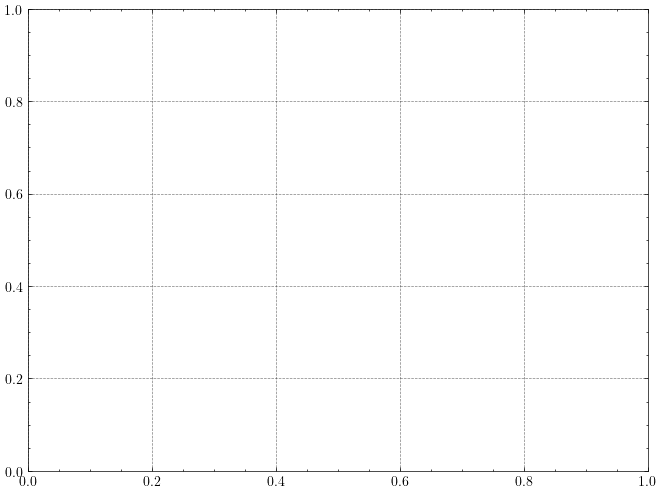

In [704]:
segment_size = 3
probabilities = pkl.load(open(f"pickles/senstivity_{segment_size}_moving_av.pkl","rb"))
fig=plt.figure(figsize=(8,6))
ax = plt.gca()
cmap_contour = 'magma'
cmap_image = 'viridis'

final_sensitivity = 1-np.mean(probabilities ,axis=-1)
#final_sensitivity = np.pad(final_sensitivity,segment_size//2, constant_values=1)

imax = ax.imshow(final_sensitivity, 
                 origin='lower', extent=[-50,50,-50,50],
                 vmin=-0.001, vmax=0.001,
                 cmap=cmap_image)
#
snr = ax.contourf(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
           levels=[2,3,4,5,6,7,8,9], alpha=0.01)

ax.contour(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
           levels=[2,3,4,5,6,7,8,9])
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=-0.2)
cbar = fig.colorbar(imax, cax=cax, orientation='vertical')
cbar.set_ticks([])
cbar.ax.annotate(
    '',
    xy=(1.5, 0.),      # arrow start (x, y) in colorbar axis coords
    xytext=(1.5, 1),  # arrow end
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='<->', lw=2),
    color='white'
)
cbar.ax.text(
    1.8, 0.75,
    "High Cross-Section Pixels",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cbar.ax.text(
    1.8, 0.25,
    "Low Cross-Section Pixels",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cax = divider.append_axes('left', size='5%', pad=-0.2)
cbar = fig.colorbar(snr, cax=cax, orientation='vertical')
cbar.set_ticks([])
cbar.ax.annotate(
    '',
    xy=(-0.5, 0.),      # arrow start (x, y) in colorbar axis coords
    xytext=(-0.5, 1),  # arrow end
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='<->', lw=2),
    color='white'
)
cbar.ax.text(
    -1.2, 0.75,
    "High Signal-to-Noise (Mass)",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)

cbar.ax.text(
    -1.2, 0.25,
    "Low Signal-to-Noise (Mass)",
    rotation=90,
    va='center',
    ha='left',
    transform=cbar.ax.transAxes,
    color='white'
)
cbar.solids.set_alpha(1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
fig.patch.set_facecolor('black')
   
fname = "plots/sensitivity_map.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

In [135]:
### simulations

In [629]:
meta, data = pkl.load(open("../data/100/obs/concat/merger_91_allcross.pkl","rb"))
all_data = []
ds_index_use = np.arange(2)/2*data.shape[0]
for i in ds_index_use:
  
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[int(i),:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)

In [ ]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]


#cdan_models = np.sort(glob(
#    f"../models/base_models/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_final.pth"
#))[:5]



all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")

fiducial = get_all_model_estimates( forward_modelled, all_models)

for segment_size in range(3,6): # pixels
    nsegments = forward_modelled.shape[-1] - segment_size + 1

    sim_probabilities = np.zeros( (forward_modelled.shape[0], nsegments, nsegments,len(all_models) ))

    
    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = forward_modelled.copy()

                segmented_data[:, :, 
                    isx:isx+segment_size,
                    isy:isy+segment_size
                ] = np.median(np.median(segmented_data,axis=-1),axis=-1)[:,:,None,None]

                
                this_estimate = (1.-get_all_model_estimates( segmented_data, all_models))
                
                for i in range(forward_modelled.shape[0]):
                    sim_probabilities[i,isx,isy,:] = this_estimate[:,i,0]






    pkl.dump([ 1-fiducial, sim_probabilities],open(f"pickles/sim_senstivity_{segment_size}_allds_moving_av.pkl","wb"))                        

100%|████████████████████████████████████████████████| 2/2 [00:00<00:00, 44.91it/s]


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/sensitivity_map.pdf'.


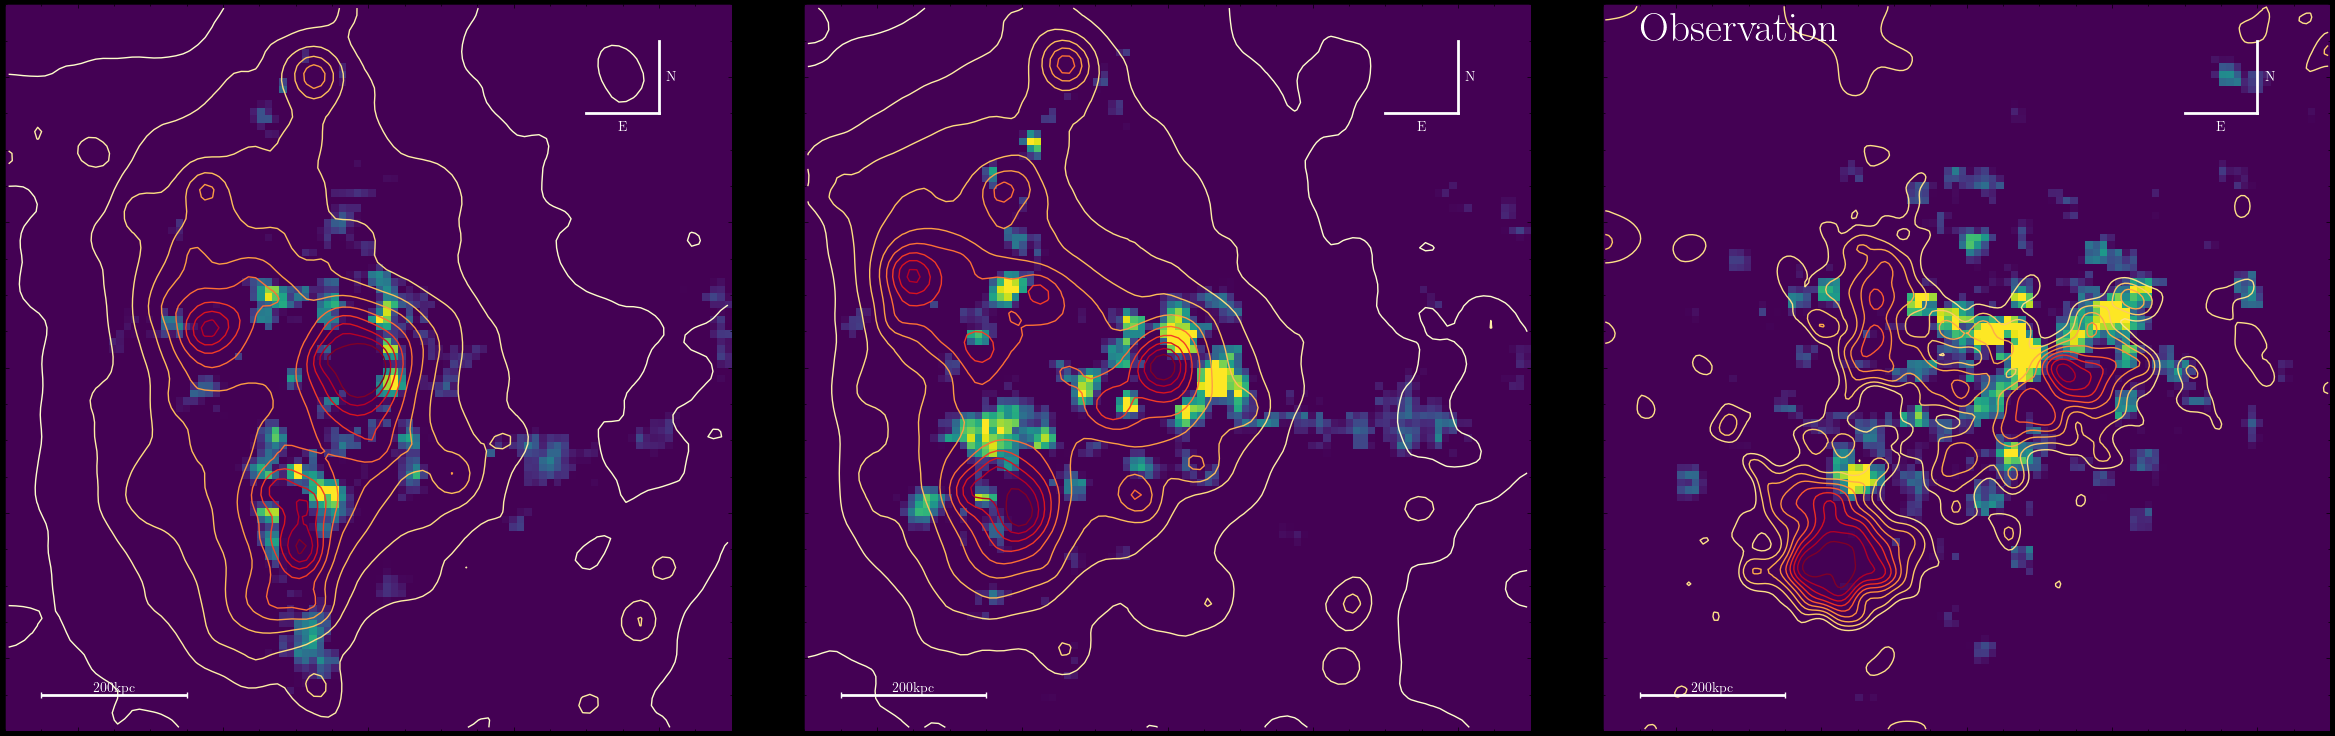

In [1142]:
segment_size = 3
sim_fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}_allds_moving_av.pkl","rb"))      


fig, axarr=plt.subplots(1, sim_probabilities.shape[0]+1,figsize=(30, 10))
fig.subplots_adjust(wspace=0.1)
kappas = []
contrast=5
ref = None
vmin=1
vmax=contrast
dmlabel = ['Collisionless','SIDM0.2','Observation']
for idm in tqdm(range(sim_probabilities.shape[0])):
    
    meta, kappa_data = pkl.load(open("../data/100/shear/merger_91_allcross.pkl","rb"))
    meta, data = pkl.load(open("../data/100/obs/concat/merger_91_allcross.pkl","rb"))
    kappa_e = kappa_data[int(ds_index_use[idm]),2,:,:]



    
    relative_prob = np.mean(sim_fiducial[:,idm,0] - sim_probabilities[idm], axis=-1)

    relative_prob /= relative_prob.std()      
        
    
    kappas.append(kappa_e)
    ax = axarr[idm]
    
    cmap_contour = 'YlOrRd'
    cmap_image = 'viridis'

    snr = ax.imshow(relative_prob, 
                     origin='lower', extent=[-50,50,-50,50],
                     vmin=vmin, vmax=vmax,
                     cmap=cmap_image)
    #

    ax.contour(gaussian_filter(kappa_e,1.5), origin='lower', 
                   extent=[-50,50,-50,50], 
               cmap=cmap_contour, 
               levels=np.linspace(0.1,1.0,10))
    
    divider = make_axes_locatable(ax)

    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
    ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
    ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
    ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
    ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
    ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
    #ax.text( 5-50, 45, dmlabel[idm], color='white', weight='bold', fontsize=20)

fiducial, probabilities = pkl.load(open(f"pickles/senstivity_{segment_size}_moving_av.pkl","rb"))

ax = axarr[-1]


obs_probs = np.mean((1-fiducial) - probabilities ,axis=-1)
obs_probs /= obs_probs.std()

snr = ax.imshow(obs_probs, 
                 origin='lower', extent=[-50,50,-50,50],
                 vmin=vmin,vmax=vmax,cmap=cmap_image)
#
#snr = ax.contourf(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
#               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
#           levels=[2,3,4,5,6,7,8,9], alpha=0.01)

ax.contour(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
               extent=[-50,50,-50,50], lw=5, cmap=cmap_contour, 
           levels=[1, 2, 3,4,5,6,7,8,9], vmin=-1)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
#fig.patch.set_facecolor('black')
ax.text( 5-50, 45, 'Observation', color='white', weight='bold', fontsize=30)
fig.set_facecolor('black')
fname = "plots/sensitivity_map.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")




## Over many simulations with only 3 halos in them (like A2744)

In [107]:
all_data = []

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
for i in range(data.shape[0]):
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)

### Find where there are common CDM and SIDM clusters

In [224]:
sidm_meta, sidm_data = pkl.load(open("../data/100/shear/darkskies_0.2_3.pkl","rb"))
cdm_meta, cdm_data = pkl.load(open("../data/100/shear/darkskies_cdm_3.pkl","rb"))
joint_sidm_set = list(set([i.replace('CDM','SIDM0.2') for i in cdm_meta['filename']]) & set(sidm_meta['filename']))

joint_cdm_set = [ i.replace('SIDM0.2','CDM') for i in joint_sidm_set]

#### Then run it to just get the fiducials

In [225]:
all_data = []

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
for ifile in joint_sidm_set:
    i = np.where( ifile == meta['filename'])[0][0]
    
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]
all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)

sidm_fiducial = get_all_model_estimates( forward_modelled, all_models)


In [226]:
all_data = []

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_cdm_3.pkl","rb"))
for ifile in joint_sidm_set:
    i = np.where( ifile.replace('SIDM0.2','CDM') == meta['filename'])[0][0]
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]
all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)

cdm_fiducial = get_all_model_estimates( forward_modelled, all_models)


#### Now a distribution of the difference betweent he CDM and SIDM

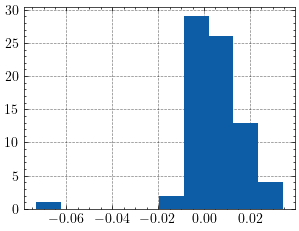

In [227]:

diff = np.mean(cdm_fiducial[:,:,0],axis=0) - np.mean(sidm_fiducial[:,:,0],axis=0)
plt.hist(diff)
best_sidm_indexes = [ np.where(i == sidm_meta['filename'])[0][0] for i in np.array(joint_sidm_set)[np.argsort(diff)]]
best_cdm_indexes = [ np.where(i == cdm_meta['filename'])[0][0] for i in np.array(joint_cdm_set)[np.argsort(diff)]]


In [230]:
all_data = []

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
for i in best_sidm_indexes:
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_cdm_3.pkl","rb"))
for i in best_cdm_indexes:
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
forward_modelled = np.stack(all_data)



In [ ]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]


#cdan_models = np.sort(glob(
#    f"../models/base_models/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_final.pth"
#))[:5]



all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")


for segment_size in range(4,5): # pixels
    nsegments = forward_modelled.shape[-1] - segment_size + 1

    sim_probabilities = np.zeros( (forward_modelled.shape[0], nsegments, nsegments,len(all_models) ))

    fiducial = get_all_model_estimates( forward_modelled, all_models)

    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = forward_modelled.copy()

                segmented_data[:, :, 
                    isx:isx+segment_size,
                    isy:isy+segment_size
                ] = np.median(np.median(segmented_data,axis=-1),axis=-1)[:,:,None,None]

                
                this_estimate = (1.-get_all_model_estimates( segmented_data, all_models))
                
                for i in range(forward_modelled.shape[0]):
                    sim_probabilities[i,isx,isy,:] = this_estimate[:,i,0]






    pkl.dump([ 1-fiducial, sim_probabilities],open(f"pickles/sim_senstivity_{segment_size}_allds_moving_av.pkl","wb"))                        

#### USe some statistics to estimate the best looking clsuters

In [281]:
fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}test.pkl","rb"))      

sidm_positive = np.array([np.sum(i[i>np.mean(i)+i.std()]) for i in np.mean(sim_probabilities[:75],axis=-1)])
cdm_positive = np.array([ np.sum(i[i>np.mean(i)+i.std()])  for i in np.mean(sim_probabilities[75:],axis=-1)])
highest_positivity_indexes = [ [i, i+sidm_std.shape[0]] for i in np.argsort( sidm_positive - cdm_positive )[::-1]]

In [307]:
fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}test.pkl","rb"))      

sidm_positive = np.array([np.sum(i[i>np.mean(i)+i.std()]) for i in np.mean(sim_probabilities[:75],axis=-1)])
cdm_positive = np.array([ np.sum(i[i>np.mean(i)])  for i in np.mean(sim_probabilities[75:],axis=-1)])
highest_positivity_indexes = [ [i, i+sidm_std.shape[0]] for i in np.argsort( cdm_positive )]

#### Now having run the infexes what are the maps like?

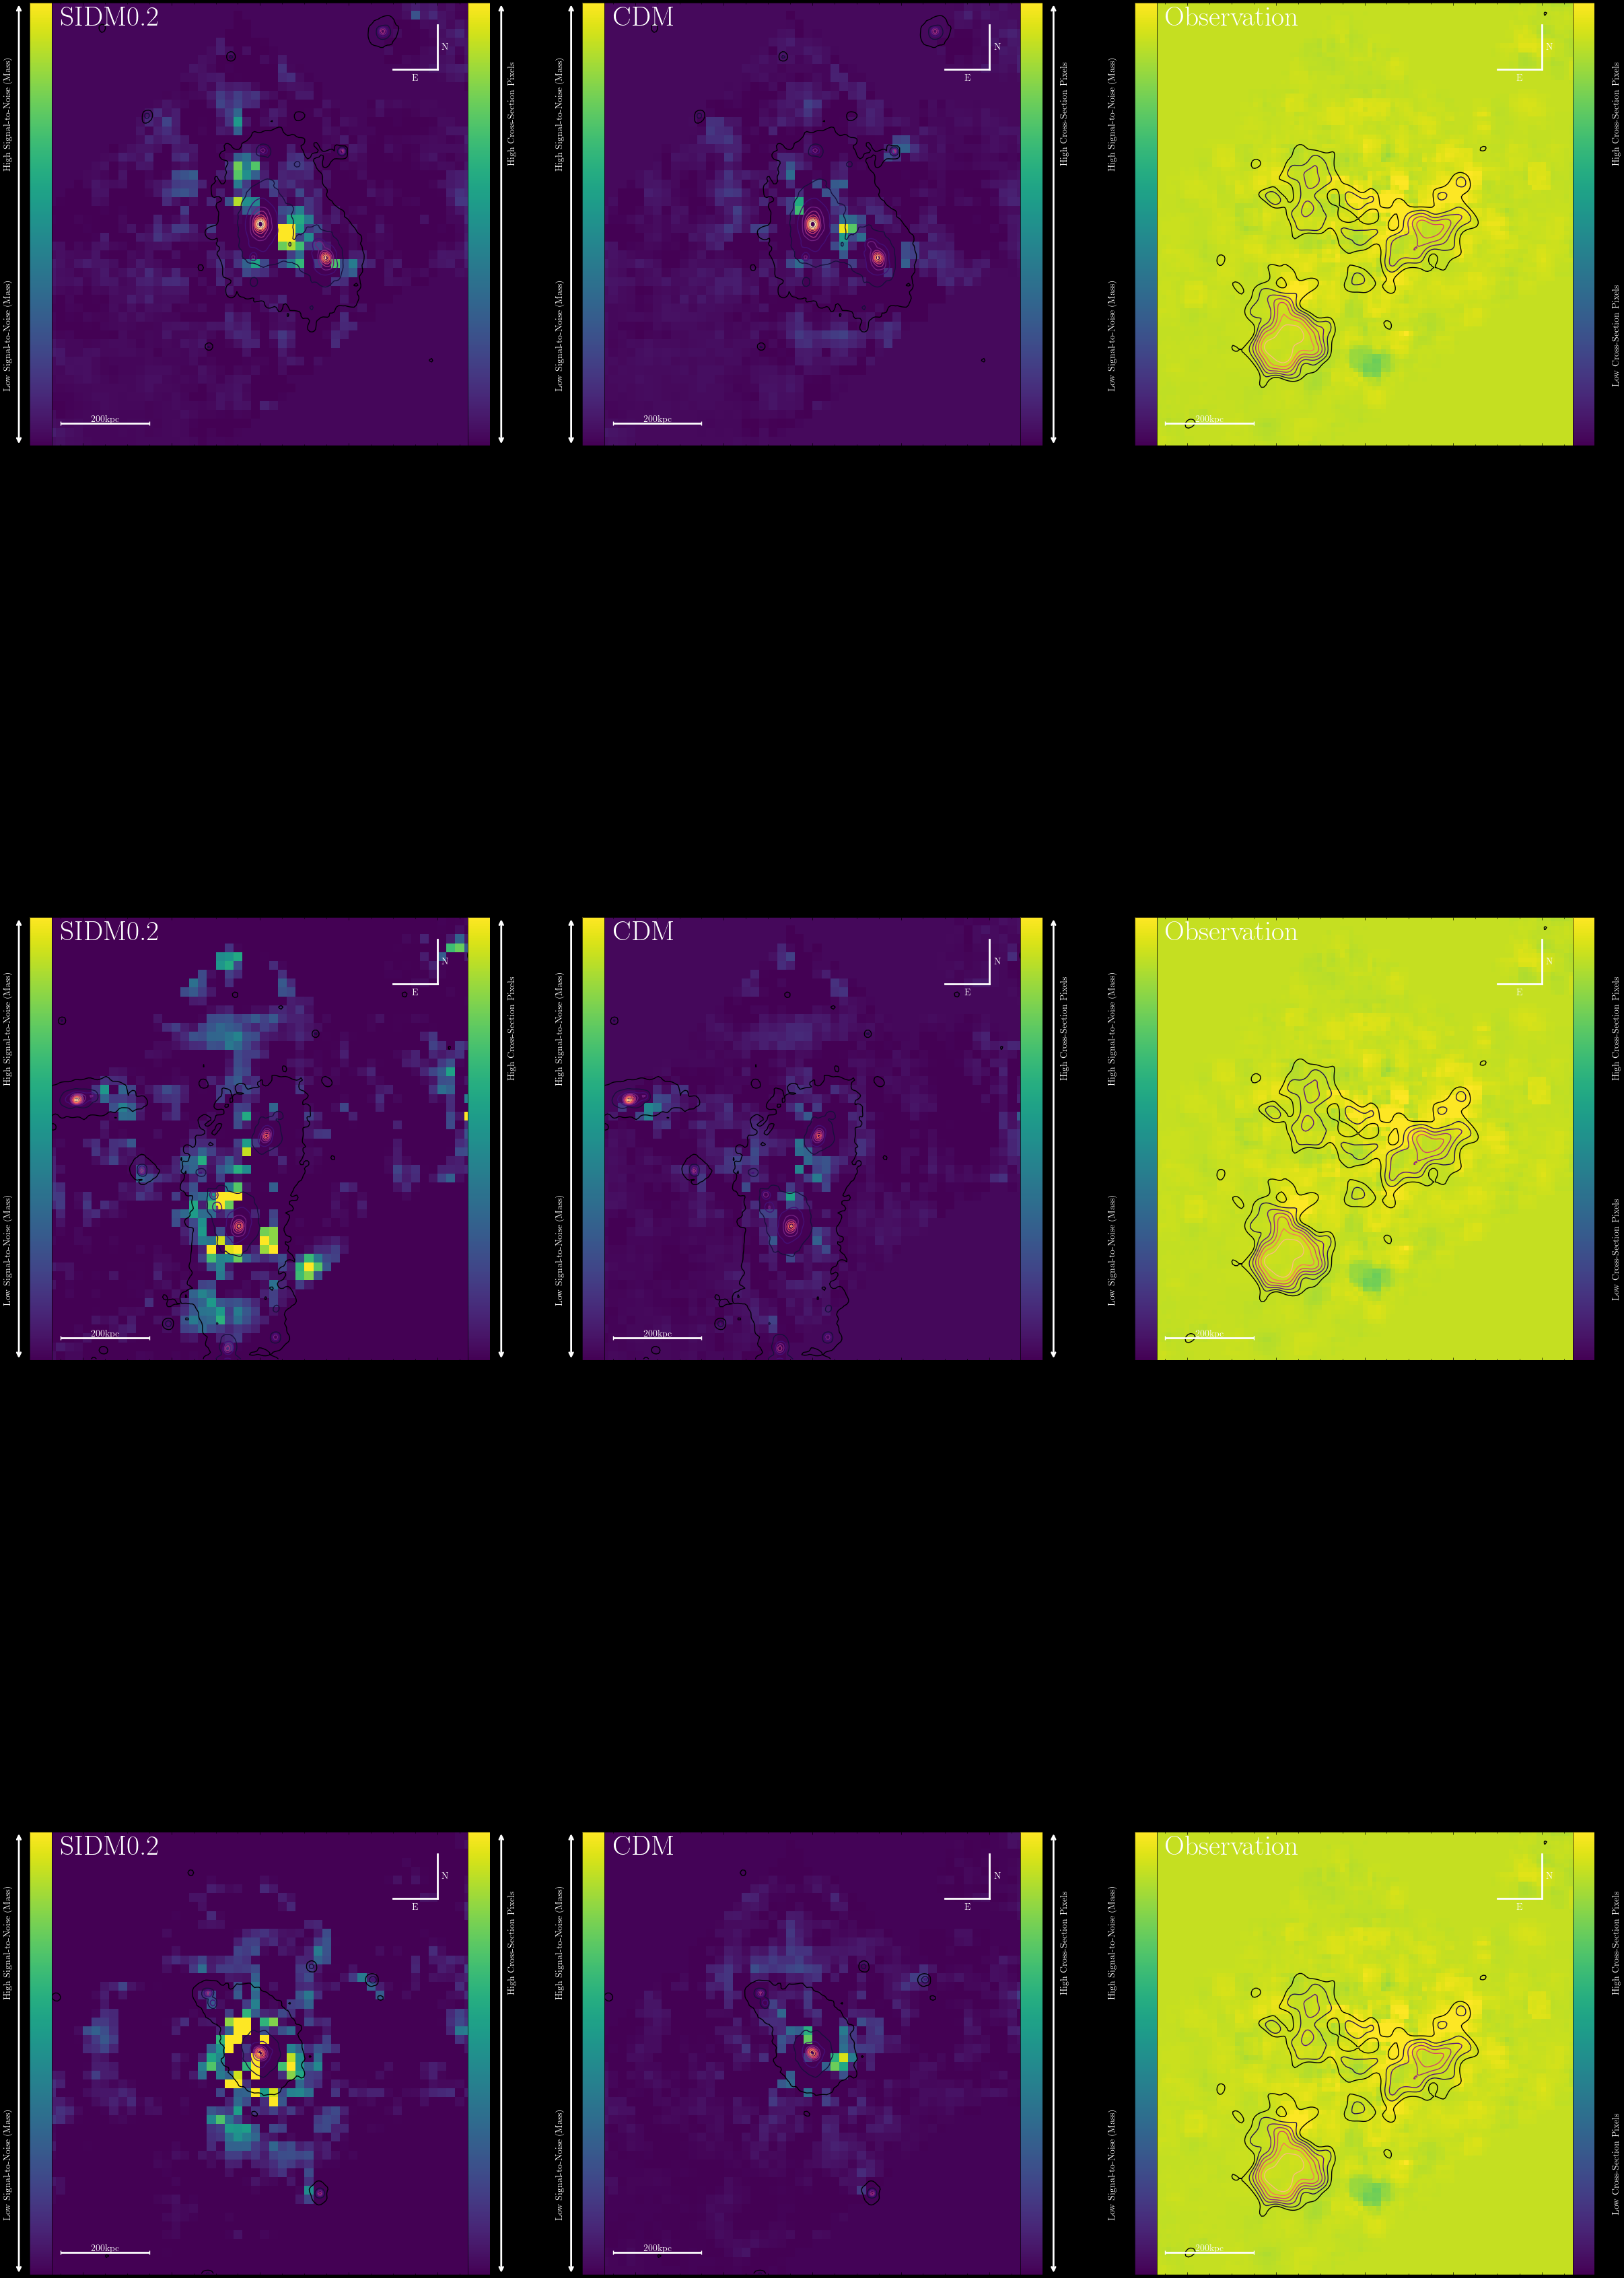

In [311]:
fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}test.pkl","rb"))      

fig, axarr_all=plt.subplots(3, 2+1,figsize=(30, 50))

kappas = []
contrast=4

dmlabel = ['SIDM0.2','CDM']
ref = None

for ihx, halo_pair in enumerate([0,2,5]):
    axarr = axarr_all[ihx]

    for idx, idm in enumerate(highest_positivity_indexes[halo_pair]):
        kappa_idx = highest_positivity_indexes[halo_pair][0]
        if idm ==0:
            meta, kappa_data = pkl.load(open("../data/100/shear/darkskies_0.2_3.pkl","rb"))
            meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
            kappa_e = kappa_data[best_sidm_indexes[kappa_idx],2,:,:]

        else:
            meta, kappa_data = pkl.load(open("../data/100/shear/darkskies_cdm_3.pkl","rb"))
            meta, data = pkl.load(open("../data/100/obs/concat/darkskies_cdm_3.pkl","rb"))
            kappa_e = kappa_data[best_cdm_indexes[kappa_idx],2,:,:]


        relative_prob = np.mean(sim_fiducial[:,idx,0] - sim_probabilities[idx], axis=-1)

        relative_prob /= relative_prob.std()/2.       
        
        kappas.append(kappa_e)
        ax = axarr[idx]

        cmap_contour = 'magma'
        cmap_image = 'viridis'
        ref = relative_prob.std()
        vmin = np.mean(relative_prob)

        vmax = np.mean(relative_prob)   + contrast*ref

        imax = ax.imshow(relative_prob, 
                         origin='lower', extent=[-50,50,-50,50],
                         vmin=vmax, vmax=vmin,
                         cmap=cmap_image)
        #

        ax.contour(zoom(kappa_e,2), origin='lower', 
                       extent=[-50,50,-50,50], 
                   cmap=cmap_contour, 
                   levels=np.linspace(0.1,1.0,10))

        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='5%', pad=-0.2)
        cbar = fig.colorbar(imax, cax=cax, orientation='vertical')
        cbar.set_ticks([])
        cbar.ax.annotate(
            '',
            xy=(1.5, 0.),      # arrow start (x, y) in colorbar axis coords
            xytext=(1.5, 1),  # arrow end
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=2,
            color='white')
        )
        cbar.ax.text(
            1.8, 0.75,
            "High Cross-Section Pixels",
            rotation=90,
            va='center',
            ha='left',
            transform=cbar.ax.transAxes,
            color='white'
        )

        cbar.ax.text(
            1.8, 0.25,
            "Low Cross-Section Pixels",
            rotation=90,
            va='center',
            ha='left',
            transform=cbar.ax.transAxes
        )

        cax = divider.append_axes('left', size='5%', pad=-0.2)
        cbar = fig.colorbar(snr, cax=cax, orientation='vertical')
        cbar.set_ticks([])
        cbar.ax.annotate(
            '',
            xy=(-0.5, 0.),      # arrow start (x, y) in colorbar axis coords
            xytext=(-0.5, 1),  # arrow end
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=2,
            color='white')
        )
        cbar.ax.text(
            -1.2, 0.75,
            "High Signal-to-Noise (Mass)",
            rotation=90,
            va='center',
            ha='left',
            transform=cbar.ax.transAxes,
            color='white'
        )

        cbar.ax.text(
            -1.2, 0.25,
            "Low Signal-to-Noise (Mass)",
            rotation=90,
            va='center',
            ha='left',
            transform=cbar.ax.transAxes,
            color='white'
        )
        cbar.solids.set_alpha(1)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(False)
        ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
        ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
        ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
        ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
        ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
        ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
        ax.text( 5-50, 45, dmlabel[idx], color='white', weight='bold', fontsize=30)
    fig.patch.set_facecolor('black')


    ax = axarr[-1]
    cmap_contour = 'magma'
    cmap_image = 'viridis'

    obs_probs = 1-np.mean(probabilities ,axis=-1)
    vmin = (obs_probs.mean() + contrast*obs_probs.std())
    vmax =(obs_probs.mean() - contrast*obs_probs.std())

    imax = ax.imshow(obs_probs, 
                     origin='lower', extent=[-50,50,-50,50],
                     vmin=vmin,vmax=vmax,cmap=cmap_image)
    #
    #snr = ax.contourf(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
    #               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
    #           levels=[2,3,4,5,6,7,8,9], alpha=0.01)

    ax.contour(zoom(obs_kappa_e/np.std(obs_kappa_b),2), origin='lower', 
                   extent=[-50,50,-50,50], lw=5, cmap=cmap_contour, 
               levels=[2, 3,4,5,6,7,8,9])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=-0.2)
    cbar = fig.colorbar(imax, cax=cax, orientation='vertical')
    cbar.set_ticks([])
    cbar.ax.annotate(
        '',
        xy=(1.5, 0.),      # arrow start (x, y) in colorbar axis coords
        xytext=(1.5, 1),  # arrow end
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='<->', lw=2),
        color='white'
    )
    cbar.ax.text(
        1.8, 0.75,
        "High Cross-Section Pixels",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )

    cbar.ax.text(
        1.8, 0.25,
        "Low Cross-Section Pixels",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )

    cax = divider.append_axes('left', size='5%', pad=-0.2)
    cbar = fig.colorbar(snr, cax=cax, orientation='vertical')
    cbar.set_ticks([])
    cbar.ax.annotate(
        '',
        xy=(-0.5, 0.),      # arrow start (x, y) in colorbar axis coords
        xytext=(-0.5, 1),  # arrow end
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='<->', lw=2),
        color='white'
    )
    cbar.ax.text(
        -1.2, 0.75,
        "High Signal-to-Noise (Mass)",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )

    cbar.ax.text(
        -1.2, 0.25,
        "Low Signal-to-Noise (Mass)",
        rotation=90,
        va='center',
        ha='left',
        transform=cbar.ax.transAxes,
        color='white'
    )
    cbar.solids.set_alpha(1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
    ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
    ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
    ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
    ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
    ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
    fig.patch.set_facecolor('black')
    ax.text( 5-50, 45, 'Observation', color='white', weight='bold', fontsize=30)

### Now find the bet index in this file (108) and run this one

In [313]:
final_best_indexes = [ highest_positivity_indexes[i][0] for i in [0,2,5] ]

In [336]:
all_data = []


meta, data = pkl.load(open("../data/100/obs/concat/darkskies_cdm_3.pkl","rb"))
for i in [108]:
    print(i)
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))

meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
for i in [108]:
    print(i)
    all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))


forward_modelled = np.stack(all_data)


108
108


In [343]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]


#cdan_models = np.sort(glob(
#    f"../models/base_models/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_final.pth"
#))[:5]



all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")


for segment_size in range(6,10): # pixels
    nsegments = forward_modelled.shape[-1] - segment_size + 1

    sim_probabilities = np.zeros( (forward_modelled.shape[0], nsegments, nsegments,len(all_models) ))

    fiducial = get_all_model_estimates( forward_modelled, all_models)

    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = forward_modelled.copy()

                segmented_data[:, :, 
                    isx:isx+segment_size,
                    isy:isy+segment_size
                ] = np.median(np.median(segmented_data,axis=-1),axis=-1)[:,:,None,None]

                
                this_estimate = (1.-get_all_model_estimates( segmented_data, all_models))
                
                for i in range(forward_modelled.shape[0]):
                    sim_probabilities[i,isx,isy,:] = this_estimate[:,i,0]






    pkl.dump([ 1-fiducial, sim_probabilities],open(f"pickles/sim_senstivity_{segment_size}_select_moving_av.pkl","wb"))                        

Found 5 Models


100%|████████████████████████████████████████████| 92/92 [08:16<00:00,  5.40s/it]


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/Sensitivty_relation.pdf'.


0

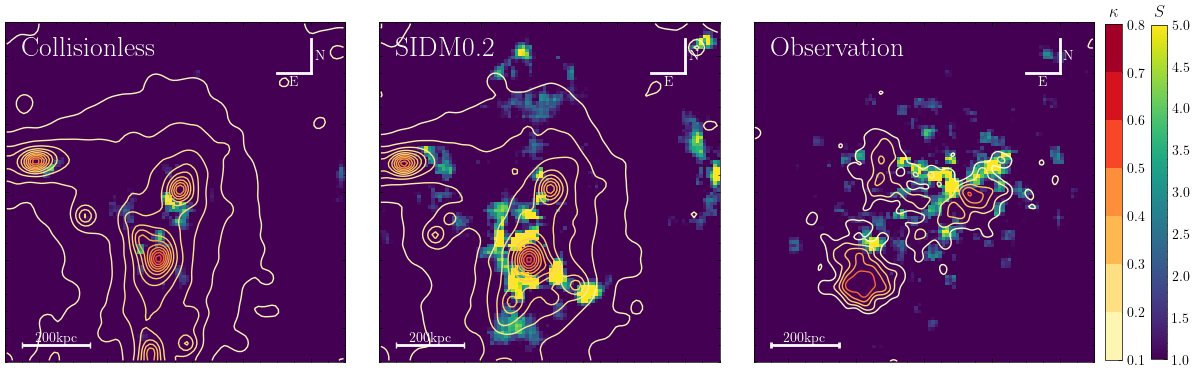

In [1162]:
segment_size = 3
sim_fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}_select_moving_av.pkl","rb"))      
cmap_contour = 'YlOrRd'
cmap_image = 'viridis'
kappa_bins = np.linspace(0.1,0.8,8)

fig, axarr=plt.subplots(1, 3,figsize=(15, 5))
fig.subplots_adjust(wspace=0.1)

kappas = []
contrast=5
vmin = 1

vmax =  contrast
ref = None
dmlabel = ['Collisionless','SIDM0.2','Observation']

h=0.7
kappa_idx = 108
for idx in range(sim_probabilities.shape[0]):
    if idx ==0:
        meta, kappa_data = pkl.load(open("../data/100/shear/darkskies_cdm_3.pkl","rb"))
        meta, data = pkl.load(open("../data/100/obs/concat/darkskies_cdm_3.pkl","rb"))
    else:
        meta, kappa_data = pkl.load(open("../data/100/shear/darkskies_0.2_3.pkl","rb"))
        meta, data = pkl.load(open("../data/100/obs/concat/darkskies_0.2_3.pkl","rb"))
        
    kappa_e = kappa_data[kappa_idx,2,:,:]/h



    relative_prob = np.mean(sim_fiducial[:,idx,0] - sim_probabilities[idx], axis=-1)

    relative_prob /= relative_prob.std()/2.
    
    kappas.append(kappa_e)
    ax = axarr[idx]

  

    snr = ax.imshow(relative_prob, 
                     origin='lower', extent=[-50,50,-50,50],
                     vmin=vmin, vmax=vmax,
                     cmap=cmap_image)
    #

    ax.contour(gaussian_filter(kappa_e,1.5), origin='lower', 
                   extent=[-50,50,-50,50], 
               cmap=cmap_contour, 
               levels=np.linspace(0.,1.0,20))

    divider = make_axes_locatable(ax)


    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2)
    ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
    ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
    ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
    ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
    ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
    ax.text( 5-50, 40, dmlabel[idx], color='white', weight='bold', fontsize=20)
    
    
fiducial, probabilities = pkl.load(open(f"pickles/senstivity_{segment_size}_moving_av.pkl","rb"))

ax = axarr[-1]


obs_probs = np.mean((1-fiducial) - probabilities ,axis=-1)
obs_probs /= obs_probs.std()



prob = ax.imshow(obs_probs, 
                 origin='lower', extent=[-50,50,-50,50],
                 vmin=vmin,vmax=vmax,cmap=cmap_image)
#
kappa = ax.contourf(zoom(obs_kappa_e,2), origin='lower', 
               extent=[-50,50,-50,50], lw=3, cmap=cmap_contour, 
           levels=kappa_bins, alpha=0.01)

ax.contour(zoom(obs_kappa_e,2), origin='lower', 
               extent=[-50,50,-50,50], lw=5, cmap=cmap_contour, 
           levels=kappa_bins)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.errorbar( 15-50, 5-50,xerr=10, capsize=2, color='white', lw=2, capthick=2)
ax.text( 15-50, 5-50, '200kpc', ha='center', va='bottom', color='white', weight='bold')
ax.plot([ 80-50, 90-50], [85-50,85-50], '-', color='white', lw=2)
ax.plot([90-50, 90-50],[95-50, 85-50], '-', color='white', lw=2)
ax.text( 85-50, 84-50, 'E', ha='center', va='top', color='white', weight='bold')
ax.text( 91-50, 90-50, 'N', ha='left', va='center', color='white', weight='bold')
#fig.patch.set_facecolor('black')
ax.text( 5-50, 40, 'Observation', color='white', weight='bold', fontsize=20)

fraction = 0.015
divider = make_axes_locatable(ax)
#cax = divider.append_axes('right', size='5%', pad=0.2)
cbar = fig.colorbar(
    prob, 
    ax=axarr, 
    orientation='vertical',
    fraction=fraction*0.96,
    pad=0.025)
cbar.ax.set_title('$S$')


#cax = divider.append_axes('right', size='5%', pad=0.4)
cbar = fig.colorbar(
    kappa, 
    ax=axarr, 
    orientation='vertical',
    fraction=fraction,
    pad=0.01)

cbar.ax.set_title('$\kappa$')
cbar.solids.set_alpha(1)
name = "plots/sensitivity_map.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")

# Correlate the cross-section with the convergence
----

In [701]:
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'
ifilter='concat'


cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))[:5]





all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")

                    

Found 5 Models


In [737]:
segment_size = 1

for dataset in ["bahamas_cdm","bahamas_0.1","bahamas_0.3","bahamas_1"]:

    meta, data = pkl.load(open(f"../data/100/obs/concat/{dataset}.pkl","rb"))
    all_data = []
    for i in range(300):
        all_data.append(dataloaders['source_val'][0].dataset.dataset.transform(torch.tensor(data[i,:2], dtype=torch.float32)))
    forward_modelled = np.stack(all_data)
    
    nsegments = forward_modelled.shape[-1] - segment_size + 1

    sim_probabilities = np.zeros( (forward_modelled.shape[0], nsegments, nsegments,len(all_models) ))

    fiducial = get_all_model_estimates( forward_modelled, all_models)

    for isx in tqdm(range(nsegments)):
          for isy in range(nsegments):
                segmented_data = forward_modelled.copy()

                segmented_data[:, :, 
                    isx:isx+segment_size,
                    isy:isy+segment_size
                ] = np.median(np.median(segmented_data,axis=-1),axis=-1)[:,:,None,None]

                
                this_estimate = (1.-get_all_model_estimates( segmented_data, all_models))
                
                for i in range(forward_modelled.shape[0]):
                    sim_probabilities[i,isx,isy,:] = this_estimate[:,i,0]






    pkl.dump([ 1-fiducial, sim_probabilities],open(f"pickles/sim_senstivity_{segment_size}_{dataset}.pkl","wb"))    
    

100%|████████████████████████████████████████| 100/100 [11:18:47<00:00, 407.27s/it]


In [1125]:
def sidm_sen( y ):
    return np.mean(y>0)
def sidm_sen_std(y):
    return np.sqrt( np.mean(y>0))

In [1126]:
segment_size = 1
bins = np.linspace(0.,0.5,20)

corr = {}
std = {}
ncomp = 0
for dataset in tqdm(["bahamas_cdm","bahamas_0.1","bahamas_0.3","bahamas_1"]):
    meta, data = pkl.load(open(f"../data/100/obs/concat/{dataset}.pkl","rb"))
    
    
    fiducial, sim_probabilities = pkl.load(open(f"pickles/sim_senstivity_{segment_size}_{dataset}.pkl","rb"))    

    rel_prob = np.array( [ np.mean(fiducial[:,i,0] - sim_probabilities[i], axis=-1) for i in range(sim_probabilities.shape[0]) if meta['ncomponents'][i] > ncomp])
     
    indexes = np.array([ i for i in  range(sim_probabilities.shape[0]) if meta['ncomponents'][i] > ncomp])
    
    rel_prob /= rel_prob.std()
    
    meta, data = pkl.load(open(f"../data/100/shear/{dataset}.pkl","rb"))
    
    x_bin_me = data[indexes,2,:,:].flatten()
    y_bin_me = rel_prob.flatten()
    
    y_bin_me = y_bin_me/np.abs(y_bin_me)
    remove = np.isfinite(y_bin_me)
    
    y_bin_me = y_bin_me[remove]
    x_bin_me = x_bin_me[remove]
    
    ycdm, x, n = binned_statistic( 
        x_bin_me, y_bin_me, bins=bins, statistic=sidm_sen)
    
    ycdmstd, x, n = binned_statistic( 
        x_bin_me, y_bin_me, bins=bins, statistic=sidm_sen_std)
    
    count, x, n = binned_statistic( 
        x_bin_me, y_bin_me, bins=bins, statistic="count")
    

    corr[dataset] = ycdm
    std[dataset] = ycdmstd/np.sqrt(count)
    
obsfiducial, obsprobabilities = pkl.load(open(f"pickles/senstivity_1.pkl","rb"))
obs_probs = np.mean((1-obsfiducial) - obsprobabilities ,axis=-1)
obs_probs /= obs_probs.std()


x_bin_me = obs_kappa_e.flatten()
y_bin_me = obs_probs.flatten()



y_bin_me = y_bin_me/np.abs(y_bin_me)
remove = np.isfinite(y_bin_me)

y_bin_me = y_bin_me[remove]
x_bin_me = x_bin_me[remove]
    
    
yobs, x, n = binned_statistic(
    x_bin_me, y_bin_me, bins=bins, statistic=sidm_sen)
yobsstd, x, n = binned_statistic(
    x_bin_me,y_bin_me, bins=bins, statistic=sidm_sen_std)
yobsn, x, n = binned_statistic(
    x_bin_me,y_bin_me, bins=bins, statistic='count')

yobsstd /= np.sqrt(yobsn)

100%|████████████████████████████████████████████████| 4/4 [00:04<00:00,  1.21s/it]


PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/Sensitivty_relation.pdf'.


0

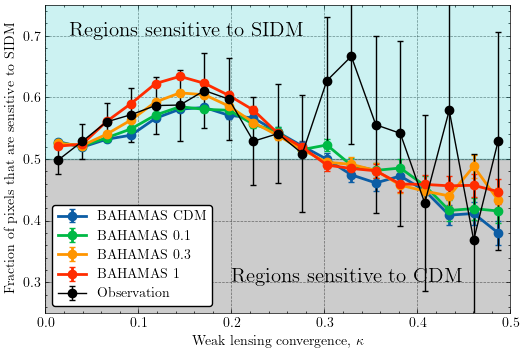

In [1151]:
fig = plt.figure(figsize=(6,4))
xc = (x[1:] + x[:-1]) / 2.
ax = plt.gca()

for dataset in corr.keys():
    ax.errorbar(xc, corr[dataset],
                std[dataset], fmt='o-', capsize=2,
            lw=2, label=' '.join(dataset.split('_')).upper())

ax.errorbar( xc, yobs, yobsstd, fmt='o-', color='k', label="Observation", capsize=2)
leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("black")
frame.set_linewidth(1.0)
ax.set_xlabel(r'Weak lensing convergence, $\kappa$')
ax.set_xlim(0,0.5)
ax.set_ylim(0.25,0.75)
#top = ax.secondary_xaxis('top')
#top.set_xticks(ax.get_xticks())
#top.set_xticklabels([f"{int((t*lenspack.utils.sigma_critical(0.3,1.65,Planck18)).value)}"
#                     for t in ax.get_xticks()])
#top.set_xlabel(r"M$_{\odot}$/pc$^2$")
#top.set_xlabel(r"M$_{\odot}$/pc$^2$")
ax.fill_between(
    [0.0,1.0],
    [0.5]*2, [1]*2,
    color='c', alpha=0.2)

ax.fill_between(
    [0.0,1.0],
    [0]*2, [0.5]*2,
    color='k', alpha=0.2)

ax.text(0.05, 0.9, "Regions sensitive to SIDM", transform=ax.transAxes, fontsize=15)
ax.text(0.4, 0.1, "Regions sensitive to CDM", transform=ax.transAxes, fontsize=15)
ax.set_ylabel("Fraction of pixels that are sensitive to SIDM")

fname = "plots/Sensitivty_relation.pdf"
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")